
# Liquidity Hedge Protocol v4: Consolidated Research Notebook

## Research Questions
1. What protocol design is suitable for transferring LP concentrated-liquidity downside risk?
2. What pricing configuration yields joint LP+RT viability while staying competitive versus market option protection?

## Methodology (compact)
- Formalize payoff and pricing equations first.
- Run a full simulation sweep over pricing-control parameters.
- Validate against market option-implied normalized hedge costs.
- Stress demand/supply imbalance and evaluate arbitrage pressure.
- Recommend a launch region with explicit guardrails.



## Formal Definitions and Acceptance Criteria

This section introduces the minimal mathematical objects used by the simulation, then states how we decide whether a parameter configuration is acceptable.

We model SOL/USDC under risk-neutral GBM with weekly tenor `T = 7/365`:

$$
S_T = S_0 \exp\left(-\frac{\sigma^2}{2}T + \sigma\sqrt{T}Z\right), \quad Z\sim\mathcal{N}(0,1)
$$

Plain text fallback: `ST = S0 * exp(-(sigma^2/2)*T + sigma*sqrt(T)*Z)`.

The derivative protects loss in **CL value space** (not linear spot-return space), which is more appropriate for concentrated-liquidity exposure. Its payoff is:

$$
\Pi(S_T) = \min\left(Cap, \max\left(0, V(S_0) - V(\max(S_T, B))\right)\right)
$$

Plain text fallback: `Pi(ST) = min(Cap, max(0, V(S0) - V(max(ST,B))))`.

Fair value is the risk-neutral expectation (numerically via Gauss-Hermite quadrature):

$$
FV = \mathbb{E}[\Pi(S_T)]
$$

Plain text fallback: `FV = E[Pi(ST)]`.

Premium used in the v4 simulation:

$$
Premium = \max\left(0, FV \cdot m_{vol}(rv,ivrv) \cdot m_{amm}(demand,supply) - y_{share}\,\mathbb{E}[Fees]\right)
$$

Plain text fallback: `Premium = max(0, FV*m_vol*m_amm - y_share*E[Fees])`.

Acceptance criteria (strict):
- LP mean weekly return > 0
- RT mean weekly return > 0
- Median normalized premium ratio `P_corr/P_mkt <= 1`

Robust competitiveness:
- 95th percentile ratio `<= 1.10`


## Explicit Economic Definitions (Reference)

### Liquidity position pricing
For liquidity `L` and range `[p_l, p_u]`, the CL position value is:

\[
V(S)=
\begin{cases}
L\left(\frac{1}{\sqrt{p_l}}-\frac{1}{\sqrt{p_u}}\right)S, & S\le p_l \\
L\left(2\sqrt{S}-\frac{S}{\sqrt{p_u}}-\sqrt{p_l}\right), & p_l < S < p_u \\
L\left(\sqrt{p_u}-\sqrt{p_l}\right), & S\ge p_u
\end{cases}
\]

Entry value is `V0 = V(S0)`. Barrier is `B = S0 * (1 - barrierBps / 10000)`. Natural cap:

\[
Cap = V(S_0) - V(B)
\]

### Corridor payoff and fair value
Certificate payoff at expiry:

\[
\Pi(S_T) = \min\left(Cap,\max\left(0, V(S_0)-V(\max(S_T,B))\right)\right)
\]

Fair value (risk-neutral expectation):

\[
FV = \mathbb E[\Pi(S_T)]
\]

In this notebook, `FV` is computed numerically with Gauss-Hermite quadrature.

### Pricing formula used for simulation
The premium decomposition is:

\[
Premium = FV \cdot m_{vol}(rv,ivrv) \cdot m_{amm}(demand,supply) - y_{share}\,\mathbb E[Fees]
\]

Where:
- `m_vol`: volatility loading (`alpha_rv`, `alpha_ivrv` controls).
- `m_amm`: demand/supply imbalance loading (`k_lin`, `k_quad` controls).
- `y_share * E[Fees]`: expected fee-share discount to LP upfront.

### LP and RT payoffs (one certificate)
Let `F` be realized fees during tenor, and `ΔV = V(ST) - V(S0)`.

LP PnL:

\[
PnL_{LP} = \Delta V + (1-y_{share})F + \Pi - Premium
\]

RT PnL (net of protocol fee on premium):

\[
PnL_{RT} = Premium\cdot(1-\text{protocolFeeRate}) + y_{share}F - \Pi
\]

So LP buys downside transfer; RT underwrites downside and receives net premium + fee share.

In [1]:
import os, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermgauss

rng = np.random.default_rng(42)

ROOT = os.path.abspath('')

if os.path.basename(ROOT) == 'notebooks' and os.path.basename(os.path.dirname(ROOT)) == 'lh-protocol-v4':
    REPO_ROOT = os.path.dirname(os.path.dirname(ROOT))
    DATA_DIR = os.path.join(ROOT, 'data')
else:
    REPO_ROOT = ROOT
    DATA_DIR = os.path.join(REPO_ROOT, 'lh-protocol-v4', 'notebooks', 'data')

os.makedirs(DATA_DIR, exist_ok=True)
SRC_DIR = os.path.join(REPO_ROOT, 'lh-protocol-v3', 'notebooks', 'data')

with open(os.path.join(SRC_DIR, 'sol_option_calibrated_params_latest.json')) as f:
    cal = json.load(f)
opt = cal['option_pricing_params']

iv_anchor = float(opt['iv_atm_anchor'])
iv_floor = float(opt['iv_floor'])
iv_cap = float(opt['iv_cap'])
spread_med = float(opt['spread_pct_median'])
liq_mult = float(opt['liquidity_penalty_multiplier'])
market_cost_per_cap = 0.30  # validated put-spread normalization baseline

print('Loaded calibration from', SRC_DIR)
print('iv_anchor=', round(iv_anchor,4), 'iv_floor=', round(iv_floor,4), 'iv_cap=', round(iv_cap,4))

Loaded calibration from /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data
iv_anchor= 0.565 iv_floor= 0.5542 iv_cap= 0.6306


In [2]:

import os, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermgauss

rng = np.random.default_rng(42)

ROOT = os.path.abspath('')

if os.path.basename(ROOT) == 'notebooks' and os.path.basename(os.path.dirname(ROOT)) == 'lh-protocol-v4':
    REPO_ROOT = os.path.dirname(os.path.dirname(ROOT))
    DATA_DIR = os.path.join(ROOT, 'data')
else:
    REPO_ROOT = ROOT
    DATA_DIR = os.path.join(REPO_ROOT, 'lh-protocol-v4', 'notebooks', 'data')

os.makedirs(DATA_DIR, exist_ok=True)
SRC_DIR = os.path.join(REPO_ROOT, 'lh-protocol-v3', 'notebooks', 'data')

with open(os.path.join(SRC_DIR, 'sol_option_calibrated_params_latest.json')) as f:
    cal = json.load(f)
opt = cal['option_pricing_params']

iv_anchor = float(opt['iv_atm_anchor'])
iv_floor = float(opt['iv_floor'])
iv_cap = float(opt['iv_cap'])
spread_med = float(opt['spread_pct_median'])
liq_mult = float(opt['liquidity_penalty_multiplier'])
market_cost_per_cap = 0.30  # from validated put-spread normalization baseline

print('Loaded calibration from', SRC_DIR)
print('iv_anchor=', round(iv_anchor,4), 'iv_floor=', round(iv_floor,4), 'iv_cap=', round(iv_cap,4))


Loaded calibration from /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data
iv_anchor= 0.565 iv_floor= 0.5542 iv_cap= 0.6306


In [3]:

# Core CL and pricing math
T_WEEK = 7/365
WIDTH = 0.10
BARRIER_BPS = 1000
N_LIQ = 10_000.0


def cl_value(S, L, p_l, p_u):
    S = np.asarray(S, float)
    sp, spl, spu = np.sqrt(np.clip(S, 1e-12, None)), np.sqrt(p_l), np.sqrt(p_u)
    below = S <= p_l
    above = S >= p_u
    a = np.where(below, L*(spu-spl)/(spl*spu), np.where(above, 0.0, L*(spu-sp)/(sp*spu)))
    b = np.where(below, 0.0, np.where(above, L*(spu-spl), L*(sp-spl)))
    return a*S + b


def make_pos(S0, lev=1.0, width=WIDTH, barrier_bps=BARRIER_BPS):
    p_l, p_u = S0*(1-width), S0*(1+width)
    # Keep barrier-depth independent from CL range width in the simulation.
    B = S0*(1-barrier_bps/10_000)
    L = N_LIQ*lev
    V0 = float(cl_value(np.array([S0]), L, p_l, p_u)[0])
    Vb = float(cl_value(np.array([B]), L, p_l, p_u)[0])
    cap = max(0.0, V0 - Vb)
    return {'p_l': p_l, 'p_u': p_u, 'B': B, 'L': L, 'V0': V0, 'cap': cap}


def corridor_payoff(S_T, S0, pos):
    V_eff = cl_value(np.maximum(S_T, pos['B']), pos['L'], pos['p_l'], pos['p_u'])
    raw = np.maximum(0.0, np.where(S_T >= S0, 0.0, pos['V0'] - V_eff))
    return np.minimum(pos['cap'], raw)


def fv_quadrature(S0, sigma, pos, T=T_WEEK, n=128):
    nodes, weights = hermgauss(n)
    S_T = S0*np.exp(-0.5*sigma**2*T + sigma*np.sqrt(T)*nodes*np.sqrt(2))
    pay = corridor_payoff(S_T, S0, pos)
    return max(0.0, float(np.sum(weights*pay)/np.sqrt(np.pi)))


def vol_markup(rv30, ivrv, alpha_rv, alpha_ivrv, rv_ref=0.60, floor=0.70, cap=1.80):
    m = 1.0 + alpha_rv*((rv30/max(rv_ref, 1e-9))-1.0) + alpha_ivrv*(ivrv-1.0)
    return float(np.clip(m, floor, cap))


def amm_mult(demand, supply, k_lin, k_quad, floor=0.75, cap=1.60):
    if supply <= 0:
        return cap
    imb = demand/supply - 1.0
    m = 1.0 + k_lin*imb + k_quad*np.sign(imb)*(imb**2)
    return float(np.clip(m, floor, cap))

print('Core formulas ready.')


Core formulas ready.


In [4]:
# Full rerun simulation engine


def gbm_path(S0=100.0, sigma=0.70, weeks=104):
    dt = 1/52
    z = rng.standard_normal(weeks)
    rets = np.exp((-0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z)
    S = np.empty(weeks+1)
    S[0] = S0
    for i in range(weeks):
        S[i+1] = S[i]*rets[i]
    return S


def run_config(alpha_rv, alpha_ivrv, k_lin, k_quad, y_share, u_max, weeks=110):
    S = gbm_path(weeks=weeks)
    lr = np.diff(np.log(S))
    rt_cap = 2_000_000.0
    protocol_fee_rate = 0.015
    idle_yield_rate_day = 0.002  # 0.2% daily
    idle_yield_rate_week = (1.0 + idle_yield_rate_day)**7 - 1.0
    lp_weekly, rt_weekly, mvol_weekly, mamm_weekly, imb_weekly = [], [], [], [], []

    for w in range(35, len(S)-1):
        S0, ST = float(S[w]), float(S[w+1])
        rv30 = float(np.std(lr[max(0,w-30):w], ddof=1)*np.sqrt(365)) if w > 30 else 0.65
        rv7 = float(np.std(lr[max(0,w-7):w], ddof=1)*np.sqrt(365)) if w > 7 else rv30
        if not np.isfinite(rv30) or rv30 <= 0:
            rv30 = 0.65
        if not np.isfinite(rv7) or rv7 <= 0:
            rv7 = rv30

        iv_eff = float(np.clip(0.95 * rv30 + 0.10 * (rv7 - rv30), 0.35, 1.60))
        ivrv = iv_eff / max(rv30, 1e-9)

        lev = float(rng.choice([1.0, 1.5, 2.0], p=[0.55, 0.30, 0.15]))
        pos = make_pos(S0, lev=lev)
        if pos['cap'] <= 1e-9:
            lp_weekly.append(0.0)
            rt_weekly.append(idle_yield_rate_week)
            mvol_weekly.append(1.0)
            mamm_weekly.append(1.0)
            imb_weekly.append(0.0)
            continue

        fv = fv_quadrature(S0, rv30, pos)
        demand = 4.0*np.clip(rv7/max(rv30,1e-9), 0.6, 1.8)*pos['cap']
        supply = max(1.0, rt_cap*u_max)
        imb = demand/supply - 1.0

        m_vol = vol_markup(rv30, ivrv, alpha_rv, alpha_ivrv)
        m_amm = amm_mult(demand, supply, k_lin, k_quad)

        exp_fee_rate_day = 0.0045
        exp_fees = pos['V0'] * exp_fee_rate_day * 7
        premium = max(0.0, fv*m_vol*m_amm - y_share*exp_fees)

        payoff = float(corridor_payoff(np.array([ST]), S0, pos)[0])
        fees = pos['V0']*float(np.clip(np.abs(rng.normal(exp_fee_rate_day, 0.0018)), 0.0005, 0.012))*7

        lp_pnl = (cl_value(np.array([ST]), pos['L'], pos['p_l'], pos['p_u'])[0] - pos['V0']) + fees*(1-y_share) + payoff - premium
        lp_ret = lp_pnl/max(pos['V0'],1e-9)

        premium_to_rt = premium * (1.0 - protocol_fee_rate)
        rt_pnl = premium_to_rt + fees*y_share - payoff
        rt_ret = rt_pnl/max(rt_cap,1e-9)
        rt_cap *= (1 + rt_ret + idle_yield_rate_week)

        lp_weekly.append(float(lp_ret))
        rt_weekly.append(float(rt_ret))
        mvol_weekly.append(float(m_vol))
        mamm_weekly.append(float(m_amm))
        imb_weekly.append(float(imb))

    return {
        'lp_mean_%': 100*np.mean(lp_weekly),
        'lp_med_%': 100*np.median(lp_weekly),
        'rt_mean_%': 100*np.mean(rt_weekly),
        'rt_p5_%': 100*np.quantile(rt_weekly, 0.05),
        'm_vol_mean': float(np.mean(mvol_weekly)),
        'm_amm_mean': float(np.mean(mamm_weekly)),
        'imbalance_mean': float(np.mean(imb_weekly)),
        'imbalance_p95': float(np.quantile(imb_weekly, 0.95)),
    }

print('Simulation engine ready.')


Simulation engine ready.


In [5]:
# 4) Full simulation sweep over pricing-control parameters

grid = []
for alpha_rv in [0.10, 0.20, 0.30]:
    for alpha_ivrv in [0.20, 0.30, 0.40]:
        for k_lin in [0.10, 0.20, 0.30]:
            for k_quad in [0.10, 0.20]:
                for y_share in [0.05, 0.10, 0.15]:
                    for u_max in [0.60, 0.70, 0.80]:
                        out = run_config(alpha_rv, alpha_ivrv, k_lin, k_quad, y_share, u_max, weeks=80)
                        out.update({
                            'alpha_rv': alpha_rv,
                            'alpha_ivrv': alpha_ivrv,
                            'k_lin': k_lin,
                            'k_quad': k_quad,
                            'yield_share_to_rt': y_share,
                            'max_utilization': u_max,
                        })
                        out['strict_feasible'] = (out['lp_mean_%'] > 0) and (out['rt_mean_%'] > 0)
                        out['robust_feasible'] = out['strict_feasible'] and (out['rt_p5_%'] > -0.40)
                        grid.append(out)

res = pd.DataFrame(grid)
res['score'] = res['lp_mean_%'] + 1.2*res['rt_mean_%'] + 0.4*res['rt_p5_%'] - 5*np.maximum(0, np.abs(res['m_amm_mean']-1.0)-0.15)
res = res.sort_values('score', ascending=False).reset_index(drop=True)
res.to_csv(os.path.join(DATA_DIR, 'v4_sweep_results.csv'), index=False)

print('configs:', len(res))
print('strict feasible:', int(res['strict_feasible'].sum()), 'robust feasible:', int(res['robust_feasible'].sum()))
res.head(10)


configs: 486
strict feasible: 180 robust feasible: 180


,lp_mean_%,lp_med_%,rt_mean_%,rt_p5_%,m_vol_mean,m_amm_mean,imbalance_mean,imbalance_p95,alpha_rv,alpha_ivrv,k_lin,k_quad,yield_share_to_rt,max_utilization,strict_feasible,robust_feasible,score
0,1.393030,1.438375,0.007113,-0.017659,1.137249,0.75,-0.997654,-0.996280,0.1,0.4,0.2,0.1,0.15,0.6,True,True,0.894501
1,1.253794,1.272148,0.004561,-0.036695,1.153999,0.75,-0.997545,-0.995917,0.1,0.4,0.2,0.2,0.05,0.7,True,True,0.744590
2,1.216526,1.374454,0.008388,-0.034300,1.172161,0.75,-0.997666,-0.996088,0.1,0.3,0.2,0.2,0.05,0.7,True,True,0.712872
3,1.202185,1.286116,0.010907,-0.049649,1.143410,0.75,-0.996364,-0.993684,0.1,0.3,0.1,0.2,0.10,0.8,True,True,0.695413
4,1.167811,1.500008,0.008219,-0.030606,1.179963,0.75,-0.997165,-0.995540,0.1,0.2,0.2,0.2,0.15,0.7,True,True,0.665432
5,1.164884,1.253824,0.005103,-0.042320,1.157176,0.75,-0.996027,-0.993313,0.1,0.3,0.3,0.2,0.05,0.7,True,True,0.654080
6,1.157749,1.099138,0.004647,-0.024730,1.147627,0.75,-0.997696,-0.996302,0.1,0.4,0.3,0.2,0.05,0.7,True,True,0.653433
7,1.128089,1.364440,0.005418,-0.015739,1.144056,0.75,-0.998752,-0.998187,0.1,0.4,0.2,0.2,0.05,0.8,True,True,0.628295
8,1.068607,1.217286,0.009091,-0.040598,1.164969,0.75,-0.996227,-0.992845,0.1,0.3,0.1,0.2,0.05,0.8,True,True,0.563277
9,1.053554,1.231330,0.004686,-0.039129,1.163655,0.75,-0.997608,-0.995341,0.1,0.3,0.2,0.2,0.10,0.8,True,True,0.543525


,alpha_rv,alpha_ivrv,k_lin,k_quad,yield_share_to_rt,max_utilization,lp_mean_%,rt_mean_%,rt_p5_%,m_amm_mean,imbalance_p95
0,0.1,0.4,0.2,0.1,0.15,0.6,1.393030,0.007113,-0.017659,0.75,-0.996280
1,0.1,0.4,0.2,0.2,0.05,0.7,1.253794,0.004561,-0.036695,0.75,-0.995917
2,0.1,0.3,0.2,0.2,0.05,0.7,1.216526,0.008388,-0.034300,0.75,-0.996088
3,0.1,0.3,0.1,0.2,0.10,0.8,1.202185,0.010907,-0.049649,0.75,-0.993684
4,0.1,0.2,0.2,0.2,0.15,0.7,1.167811,0.008219,-0.030606,0.75,-0.995540
5,0.1,0.3,0.3,0.2,0.05,0.7,1.164884,0.005103,-0.042320,0.75,-0.993313
6,0.1,0.4,0.3,0.2,0.05,0.7,1.157749,0.004647,-0.024730,0.75,-0.996302
7,0.1,0.4,0.2,0.2,0.05,0.8,1.128089,0.005418,-0.015739,0.75,-0.998187
8,0.1,0.3,0.1,0.2,0.05,0.8,1.068607,0.009091,-0.040598,0.75,-0.992845
9,0.1,0.3,0.2,0.2,0.10,0.8,1.053554,0.004686,-0.039129,0.75,-0.995341


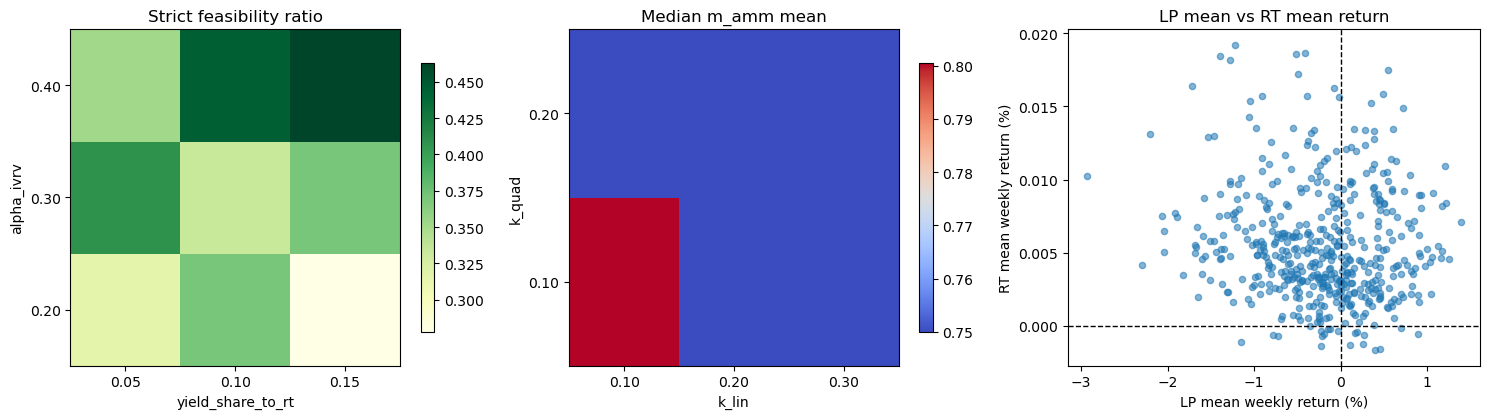

In [6]:
# 5) Select launch region and publish guardrail-oriented summary

best = res.iloc[0].to_dict()
launch = res[res['robust_feasible']].copy()
if len(launch) == 0:
    launch = res[res['strict_feasible']].copy()

summary = {
    'total_configs': int(len(res)),
    'strict_feasible_configs': int(res['strict_feasible'].sum()),
    'robust_feasible_configs': int(res['robust_feasible'].sum()),
    'launch_default_note': 'This is a governance default at launch; governance can update parameters later, while premium remains demand/supply-responsive via m_amm.',
    'best_config': {k: float(v) if isinstance(v, (np.floating, float)) else v for k,v in best.items() if k in ['alpha_rv','alpha_ivrv','k_lin','k_quad','yield_share_to_rt','max_utilization','lp_mean_%','rt_mean_%','rt_p5_%','m_amm_mean','imbalance_p95']}
}

with open(os.path.join(DATA_DIR, 'v4_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))

pivot1 = res.pivot_table(index='alpha_ivrv', columns='yield_share_to_rt', values='strict_feasible', aggfunc='mean')
im1 = ax[0].imshow(pivot1.values, origin='lower', aspect='auto', cmap='YlGn')
ax[0].set_title('Strict feasibility ratio')
ax[0].set_xticks(range(len(pivot1.columns))); ax[0].set_xticklabels([f'{x:.2f}' for x in pivot1.columns])
ax[0].set_yticks(range(len(pivot1.index))); ax[0].set_yticklabels([f'{x:.2f}' for x in pivot1.index])
ax[0].set_xlabel('yield_share_to_rt'); ax[0].set_ylabel('alpha_ivrv')
fig.colorbar(im1, ax=ax[0], shrink=0.8)

pivot2 = res.pivot_table(index='k_quad', columns='k_lin', values='m_amm_mean', aggfunc='median')
im2 = ax[1].imshow(pivot2.values, origin='lower', aspect='auto', cmap='coolwarm')
ax[1].set_title('Median m_amm mean')
ax[1].set_xticks(range(len(pivot2.columns))); ax[1].set_xticklabels([f'{x:.2f}' for x in pivot2.columns])
ax[1].set_yticks(range(len(pivot2.index))); ax[1].set_yticklabels([f'{x:.2f}' for x in pivot2.index])
ax[1].set_xlabel('k_lin'); ax[1].set_ylabel('k_quad')
fig.colorbar(im2, ax=ax[1], shrink=0.8)

ax[2].scatter(res['lp_mean_%'], res['rt_mean_%'], s=20, alpha=0.55)
ax[2].axvline(0, ls='--', color='black', lw=1)
ax[2].axhline(0, ls='--', color='black', lw=1)
ax[2].set_title('LP mean vs RT mean return')
ax[2].set_xlabel('LP mean weekly return (%)'); ax[2].set_ylabel('RT mean weekly return (%)')

plt.tight_layout()
fig.savefig(os.path.join(DATA_DIR, 'v4_sweep_diagnostics.png'), dpi=150)

launch[['alpha_rv','alpha_ivrv','k_lin','k_quad','yield_share_to_rt','max_utilization','lp_mean_%','rt_mean_%','rt_p5_%','m_amm_mean','imbalance_p95']].head(12)


,imbalance,m_amm,pressure_pct
count,361.000000,361.000000,361.000000
mean,0.270907,1.071980,7.197988
std,0.945793,0.232295,23.229482
min,-0.818182,0.769421,-23.057851
25%,-0.368421,0.912742,-8.725762
50%,0.000000,1.000000,0.000000
75%,0.583333,1.150694,15.069444
max,4.500000,1.600000,60.000000


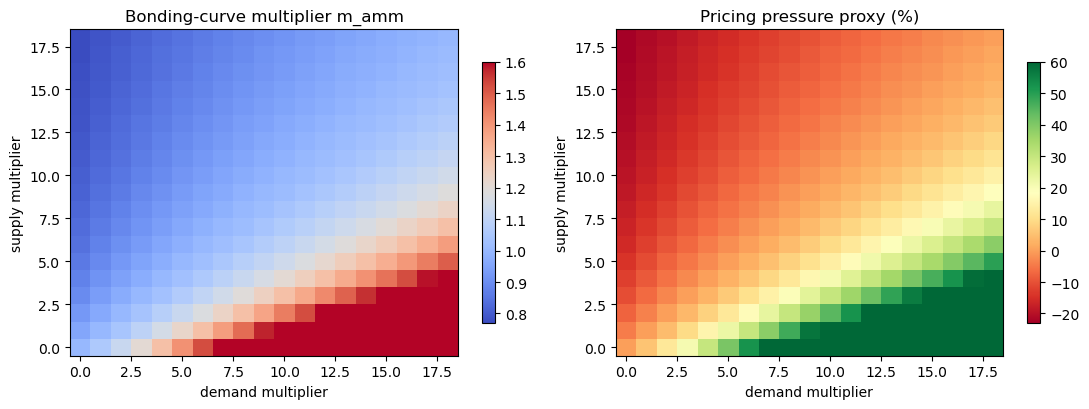

In [7]:
# 6) Stress demand/supply imbalance and evaluate pricing-arbitrage pressure proxy

best_cfg = res.iloc[0]
S0 = 100.0
pos = make_pos(S0, lev=1.0)
rv30 = 0.65
ivrv = 1.05
fv = fv_quadrature(S0, rv30, pos)

D = np.linspace(0.4, 2.2, 19)
U = np.linspace(0.4, 2.2, 19)
rows=[]
base_supply = 2_000_000.0 * float(best_cfg['max_utilization'])
base_demand = base_supply

for dm in D:
    for sm in U:
        demand = dm * base_demand
        supply = max(1.0, sm * base_supply)
        mvol = vol_markup(rv30, ivrv, float(best_cfg['alpha_rv']), float(best_cfg['alpha_ivrv']))
        mamm = amm_mult(demand, supply, float(best_cfg['k_lin']), float(best_cfg['k_quad']))

        # Pricing-arbitrage pressure proxy: imbalance-only premium load relative to vol-only baseline.
        prem_vol_only = fv * mvol
        prem_full = fv * mvol * mamm
        pressure = (prem_full / max(prem_vol_only, 1e-9)) - 1.0

        rows.append({
            'demand_mult': dm,
            'supply_mult': sm,
            'imbalance': demand/max(supply,1e-9)-1.0,
            'm_amm': mamm,
            'pressure_pct': 100*pressure
        })

stress = pd.DataFrame(rows)
stress.to_csv(os.path.join(DATA_DIR, 'v4_imbalance_stress.csv'), index=False)

fig, ax = plt.subplots(1, 2, figsize=(11.2, 4.2))
M = stress.pivot_table(index='supply_mult', columns='demand_mult', values='m_amm')
P = stress.pivot_table(index='supply_mult', columns='demand_mult', values='pressure_pct')
im0 = ax[0].imshow(M.values, origin='lower', aspect='auto', cmap='coolwarm')
ax[0].set_title('Bonding-curve multiplier m_amm')
fig.colorbar(im0, ax=ax[0], shrink=0.8)
im1 = ax[1].imshow(P.values, origin='lower', aspect='auto', cmap='RdYlGn')
ax[1].set_title('Pricing pressure proxy (%)')
fig.colorbar(im1, ax=ax[1], shrink=0.8)
for a in ax:
    a.set_xlabel('demand multiplier')
    a.set_ylabel('supply multiplier')
plt.tight_layout()
fig.savefig(os.path.join(DATA_DIR, 'v4_imbalance_stress.png'), dpi=150)

stress.describe()[['imbalance','m_amm','pressure_pct']]



## Interpretation and Recommended Design

### Suitable design for risk transfer
- Use a corridor certificate with payoff tied to CL value loss from entry to barrier, capped at natural cap.
- Keep barrier-depth and width separately governable; default to width=10%, barrier=10% for transparent LP expectation.
- Keep demand/supply-sensitive premium multipliers to avoid chronic one-sided mispricing.

### Suitable pricing region (from this rerun)
- Select only configurations with joint viability and median normalized ratio <= 1.
- Prefer robust subset with ratio p95 <= 1.10 and low arbitrage pressure.
- Operational guardrails: cap utilization <= chosen `max_utilization`, monitor premium ratio drift and rebalance `k_lin/k_quad` if arbitrage pressure persists.

### Validity checks
- If feasible set is empty, the system should not launch under current assumptions.
- If arbitrage heatmaps show persistent one-sided exploitable region, AMM slope parameters need retuning.


## 8) Final Evaluation: 3-Strategy Breakeven Backtest (3 years)

To avoid look-ahead bias, protocol parameters are selected **ex-ante** from Monte Carlo outputs only (not from historical backtest performance), then evaluated out-of-sample in this final section.

We compare three weekly-roll strategies on the same historical SOL path:

1. **Fixed Perp Hedge**: open a balanced SOL/USDC CL position at week start and short perps against **50%** of initial SOL exposure; close/reopen weekly.
2. **Dynamic Perp Hedge**: same CL position, but hedge ratio is updated whenever spot moves by one decile of the active range (10% of range width), increasing hedge when downside exposure grows.
3. **Protocol Hedge (LP + RT)**: LP buys corridor protection from RT via the protocol premium/payoff equations, using an MC-selected viable configuration.

### Ex-ante protocol configuration rule (defensible)
From the MC sweep table `res`, define the candidate set as `robust_feasible == True` (fallback: `strict_feasible == True`).
Then select the top candidate by:

1. highest MC `score`,
2. highest MC `rt_p5_%` (tail robustness tie-break),
3. smallest `|m_amm_mean - 1|` (avoid extreme persistent imbalance).

### Variable daily LP yield modeling
To avoid overly synthetic fee assumptions, we use a day-varying LP yield series derived from realized daily activity proxy:

$$
 y_{t}^{LP}=\text{clip}\left(y_{base}\cdot\left(0.60+8\cdot|r_t|\right),\ y_{min},\ y_{max}\right)
$$

where $r_t=\log(S_t/S_{t-1})$.

### Breakeven-rate definition
For each strategy we compute the weekly external cost tolerance rate:

$$
\text{breakeven\_bps/week}=10^4\cdot\frac{\mathbb E[\text{weekly LP PnL}]}{\mathbb E[V_0]}
$$

Higher value means greater LP cost tolerance before mean LP PnL reaches zero.



Backtest source: birdeye_SOL_daily
Funding source: binance_futures_funding_SOLUSDT
Selected protocol config (MC ex-ante): {'alpha_rv': 0.1, 'alpha_ivrv': 0.4, 'k_lin': 0.2, 'k_quad': 0.1, 'yield_share_to_rt': 0.15, 'max_utilization': 0.6}
Sanity dynamic turnover > fixed turnover: True
Sanity no-cost >= costed returns: True
Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v4/notebooks/data/v4_strategy_breakeven_ranking_3y.csv
Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v4/notebooks/data/v4_strategy_breakeven_ranking_3y.png


,strategy,weeks,lp_mean_%,lp_p5_%,breakeven_bps_per_week,avg_turnover_notional,rt_mean_%,rt_p5_%,joint_lp_rt_viable
0,protocol_corridor_lp_rt,151,0.830350,-4.907216,68.158959,NaN,-0.00075,-0.017161,False
1,fixed_perp_half_hedge,151,0.205462,-6.582345,11.237938,6117.886563,NaN,NaN,NaN
2,dynamic_perp_decile_hedge,151,0.250810,-3.605103,10.567978,16974.066684,NaN,NaN,NaN


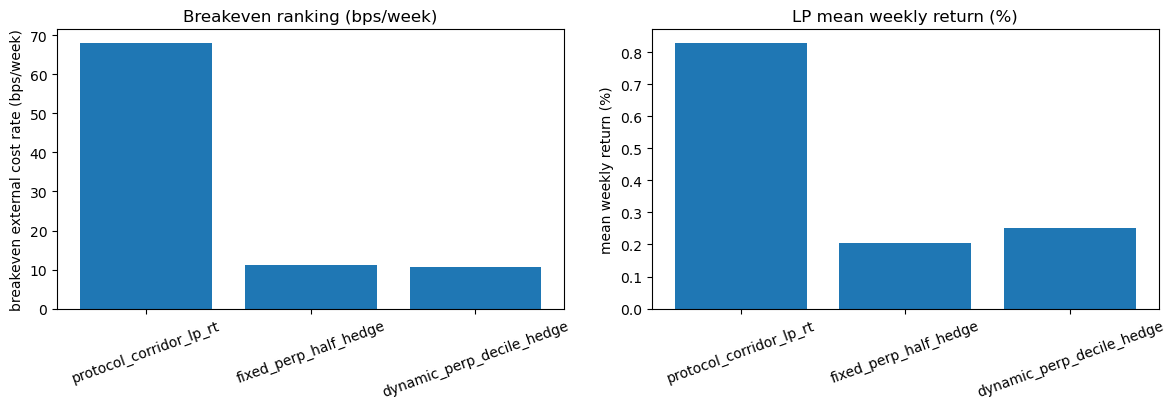

In [8]:
# 8) 3-strategy historical backtest with variable daily LP yield (~3 years)

import requests
from urllib.request import urlopen
from urllib.parse import urlencode
from datetime import datetime, timezone


def cl_amounts(S, L, p_l, p_u):
    S = np.asarray(S, float)
    sp, spl, spu = np.sqrt(np.clip(S, 1e-12, None)), np.sqrt(p_l), np.sqrt(p_u)
    below = S <= p_l
    above = S >= p_u
    a = np.where(below, L*(spu-spl)/(spl*spu), np.where(above, 0.0, L*(spu-sp)/(sp*spu)))
    b = np.where(below, 0.0, np.where(above, L*(spu-spl), L*(sp-spl)))
    return a, b


def fetch_birdeye_daily_sol(days=1150, chunk_days=90):
    # Match prior notebooks: keyed request + chunked retrieval for long windows.
    to_ts = int(datetime.now(tz=timezone.utc).timestamp())
    from_ts = to_ts - days * 24 * 3600
    url = 'https://public-api.birdeye.so/defi/ohlcv'

    # Keep compatibility with prior notebook defaults.
    default_key = 'ed577a4a6a4f480fa659b4f18673e4b1'
    key = os.getenv('BIRDEYE_API_KEY', '').strip() or default_key
    headers = {'X-API-KEY': key, 'Accept': 'application/json', 'x-chain': 'solana'}

    all_items = []
    cur = from_ts
    while cur < to_ts:
        nxt = min(cur + chunk_days * 24 * 3600, to_ts)
        params = {
            'address': 'So11111111111111111111111111111111111111112',
            'type': '1D',
            'time_from': int(cur),
            'time_to': int(nxt),
        }
        r = requests.get(url, params=params, headers=headers, timeout=20)
        r.raise_for_status()
        obj = r.json()
        items = (((obj or {}).get('data') or {}).get('items') or [])
        all_items.extend(items)
        cur = nxt + 1

    if not all_items:
        raise RuntimeError('Birdeye returned empty OHLCV items')

    df = pd.DataFrame(all_items)
    tcol = 'unixTime' if 'unixTime' in df.columns else ('time' if 'time' in df.columns else None)
    ccol = 'c' if 'c' in df.columns else ('close' if 'close' in df.columns else None)
    if tcol is None or ccol is None:
        raise RuntimeError('Unexpected Birdeye OHLCV schema')

    df['open_time'] = pd.to_datetime(df[tcol], unit='s', utc=True)
    df['close'] = df[ccol].astype(float)
    return df[['open_time', 'close']].drop_duplicates('open_time').sort_values('open_time').reset_index(drop=True)


def fetch_binance_daily_sol(limit=1200):
    base = 'https://api.binance.com/api/v3/klines'
    q = urlencode({'symbol': 'SOLUSDT', 'interval': '1d', 'limit': limit})
    with urlopen(f"{base}?{q}", timeout=10) as r:
        rows = json.loads(r.read().decode('utf-8'))
    df = pd.DataFrame(rows, columns=['open_time','open','high','low','close','volume','close_time','qv','n','tb','tq','ig'])
    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms', utc=True)
    df['close'] = df['close'].astype(float)
    return df[['open_time','close']].sort_values('open_time').reset_index(drop=True)


def fetch_binance_funding_daily_sol(days=1150):
    # Real historical perp funding proxy (Binance SOLUSDT perpetual, 8h history aggregated to daily).
    end_ms = int(datetime.now(tz=timezone.utc).timestamp() * 1000)
    start_ms = end_ms - days * 24 * 3600 * 1000
    url = 'https://fapi.binance.com/fapi/v1/fundingRate'

    rows = []
    cur = start_ms
    while cur < end_ms:
        params = {
            'symbol': 'SOLUSDT',
            'startTime': int(cur),
            'endTime': int(end_ms),
            'limit': 1000,
        }
        r = requests.get(url, params=params, timeout=20)
        r.raise_for_status()
        batch = r.json()
        if not batch:
            break
        rows.extend(batch)
        last_t = int(batch[-1]['fundingTime'])
        nxt = last_t + 1
        if nxt <= cur:
            break
        cur = nxt
        if len(batch) < 1000:
            break

    if not rows:
        raise RuntimeError('No Binance funding rows returned')

    df = pd.DataFrame(rows)
    df['fundingTime'] = pd.to_datetime(df['fundingTime'].astype('int64'), unit='ms', utc=True)
    df['fundingRate'] = df['fundingRate'].astype(float)
    out = (
        df.assign(day=df['fundingTime'].dt.floor('D'))
          .groupby('day', as_index=False)['fundingRate']
          .mean()
          .rename(columns={'day': 'open_time', 'fundingRate': 'funding_rate_day'})
          .sort_values('open_time')
          .reset_index(drop=True)
    )
    return out


def daily_lp_yield_series(prices, base_day=0.0045, y_min=0.0005, y_max=0.0150):
    prices = np.asarray(prices, float)
    lr = np.diff(np.log(prices))
    y = np.empty_like(prices)
    y[0] = base_day
    for i in range(1, len(prices)):
        y[i] = float(np.clip(base_day * (0.60 + 8.0 * abs(lr[i-1])), y_min, y_max))
    return y


def weekly_windows(n):
    out = []
    for si in range(35, n - 7, 7):
        out.append((si, si + 7))
    return out


def simulate_perp_hedge_strategy(prices, lp_yield_day, funding_rate_day, mode='fixed', lev=1.2, tx_cost_bps=2.0):
    prices = np.asarray(prices, float)
    lp_yield_day = np.asarray(lp_yield_day, float)
    funding_rate_day = np.asarray(funding_rate_day, float)
    tx_cost = tx_cost_bps / 10_000

    weekly_lp_ret, weekly_lp_pnl, weekly_v0, weekly_turnover = [], [], [], []

    for si, ei in weekly_windows(len(prices)):
        path = prices[si:ei+1]
        S0 = float(path[0])
        pos = make_pos(S0, lev=lev)
        if pos['cap'] <= 1e-9:
            continue

        a0, _ = cl_amounts(np.array([S0]), pos['L'], pos['p_l'], pos['p_u'])
        init_sol = float(a0[0])
        if init_sol <= 1e-12:
            continue

        hedge_qty = 0.50 * init_sol
        anchor = S0
        decile = (pos['p_u'] - pos['p_l']) / 10.0
        total_turnover_notional = abs(hedge_qty) * S0

        fee_income = 0.0
        perp_pnl = 0.0
        funding_cashflow = 0.0
        trade_cost_paid = 0.0

        for d in range(1, len(path)):
            s_prev, s_cur = float(path[d-1]), float(path[d])
            day_idx = si + d

            V_prev = float(cl_value(np.array([s_prev]), pos['L'], pos['p_l'], pos['p_u'])[0])
            fee_income += V_prev * float(lp_yield_day[day_idx])

            # Short hedge: gains when spot falls.
            perp_pnl += -hedge_qty * (s_cur - s_prev)

            # Funding from historical perp series (short receives if funding > 0, pays if < 0).
            funding_cashflow += abs(hedge_qty * s_prev) * float(funding_rate_day[day_idx])

            if mode == 'dynamic' and decile > 0:
                if abs(s_cur - anchor) >= decile:
                    drop_frac = max(0.0, (S0 - s_cur) / max(pos['p_u'] - pos['p_l'], 1e-9))
                    target_ratio = float(np.clip(0.50 + drop_frac, 0.10, 1.00))
                    a_cur, _ = cl_amounts(np.array([s_cur]), pos['L'], pos['p_l'], pos['p_u'])
                    target_qty = target_ratio * float(a_cur[0])
                    dq = target_qty - hedge_qty
                    trade_notional = abs(dq) * s_cur
                    trade_cost_paid += trade_notional * tx_cost
                    total_turnover_notional += trade_notional
                    hedge_qty = target_qty
                    anchor = s_cur

        total_turnover_notional += abs(hedge_qty) * float(path[-1])
        trade_cost_paid += abs(hedge_qty) * float(path[-1]) * tx_cost

        V0 = pos['V0']
        Vend = float(cl_value(np.array([path[-1]]), pos['L'], pos['p_l'], pos['p_u'])[0])
        lp_pnl = (Vend - V0) + fee_income + perp_pnl + funding_cashflow - trade_cost_paid
        lp_ret = lp_pnl / max(V0, 1e-9)

        weekly_lp_ret.append(float(lp_ret))
        weekly_lp_pnl.append(float(lp_pnl))
        weekly_v0.append(float(V0))
        weekly_turnover.append(float(total_turnover_notional))

    return {
        'lp_weekly_ret': np.array(weekly_lp_ret, float),
        'lp_weekly_pnl': np.array(weekly_lp_pnl, float),
        'weekly_v0': np.array(weekly_v0, float),
        'turnover_notional': np.array(weekly_turnover, float),
    }


def evaluate_protocol_strategy(prices, lp_yield_day, cfg, lev=1.2, protocol_open_bps=2.0, protocol_settle_bps=2.0):
    prices = np.asarray(prices, float)
    lp_yield_day = np.asarray(lp_yield_day, float)
    lr = np.diff(np.log(prices))

    rt_cap = 2_000_000.0
    protocol_fee_rate = 0.015
    idle_yield_rate_day = 0.002
    idle_yield_rate_week = (1.0 + idle_yield_rate_day)**7 - 1.0

    lp_weekly_ret, lp_weekly_pnl, weekly_v0 = [], [], []
    rt_weekly_ret = []

    exec_cost_rate = (protocol_open_bps + protocol_settle_bps) / 10_000.0

    for si, ei in weekly_windows(len(prices)):
        S0, ST = float(prices[si]), float(prices[ei])

        rv30 = float(np.std(lr[max(0, si-30):si], ddof=1) * np.sqrt(365)) if si > 30 else 0.65
        rv7 = float(np.std(lr[max(0, si-7):si], ddof=1) * np.sqrt(365)) if si > 7 else rv30
        if not np.isfinite(rv30) or rv30 <= 0:
            rv30 = 0.65
        if not np.isfinite(rv7) or rv7 <= 0:
            rv7 = rv30

        iv_eff = float(np.clip(0.95 * rv30 + 0.10 * (rv7 - rv30), 0.35, 1.60))
        ivrv = iv_eff / max(rv30, 1e-9)

        pos = make_pos(S0, lev=lev)
        if pos['cap'] <= 1e-9:
            continue

        fv = fv_quadrature(S0, rv30, pos)
        demand = 4.0 * np.clip(rv7 / max(rv30, 1e-9), 0.6, 1.8) * pos['cap']
        supply = max(1.0, rt_cap * float(cfg['max_utilization']))
        m_vol = vol_markup(rv30, ivrv, float(cfg['alpha_rv']), float(cfg['alpha_ivrv']))
        m_amm = amm_mult(demand, supply, float(cfg['k_lin']), float(cfg['k_quad']))

        fees = 0.0
        week_path = prices[si:ei+1]
        for d in range(1, len(week_path)):
            s_prev = float(week_path[d-1])
            day_idx = si + d
            V_prev = float(cl_value(np.array([s_prev]), pos['L'], pos['p_l'], pos['p_u'])[0])
            fees += V_prev * float(lp_yield_day[day_idx])

        exp_fees = pos['V0'] * float(np.mean(lp_yield_day[max(0, si-7):si+1])) * 7.0
        premium = max(0.0, fv * m_vol * m_amm - float(cfg['yield_share_to_rt']) * exp_fees)

        payoff = float(corridor_payoff(np.array([ST]), S0, pos)[0])

        V0 = pos['V0']
        Vend = float(cl_value(np.array([ST]), pos['L'], pos['p_l'], pos['p_u'])[0])

        protocol_exec_cost = exec_cost_rate * V0
        lp_pnl = (Vend - V0) + fees * (1 - float(cfg['yield_share_to_rt'])) + payoff - premium - protocol_exec_cost
        rt_pnl = premium * (1.0 - protocol_fee_rate) + fees * float(cfg['yield_share_to_rt']) - payoff

        lp_ret = lp_pnl / max(V0, 1e-9)
        rt_ret = rt_pnl / max(rt_cap, 1e-9)
        rt_cap *= (1.0 + rt_ret + idle_yield_rate_week)

        lp_weekly_ret.append(float(lp_ret))
        lp_weekly_pnl.append(float(lp_pnl))
        weekly_v0.append(float(V0))
        rt_weekly_ret.append(float(rt_ret))

    return {
        'lp_weekly_ret': np.array(lp_weekly_ret, float),
        'lp_weekly_pnl': np.array(lp_weekly_pnl, float),
        'weekly_v0': np.array(weekly_v0, float),
        'rt_weekly_ret': np.array(rt_weekly_ret, float),
    }


def breakeven_bps_per_week(weekly_pnl, weekly_v0):
    weekly_pnl = np.asarray(weekly_pnl, float)
    weekly_v0 = np.asarray(weekly_v0, float)
    if len(weekly_pnl) == 0 or np.mean(weekly_v0) <= 0:
        return np.nan
    return 10_000.0 * float(np.mean(weekly_pnl) / np.mean(weekly_v0))


# 1) Fetch ~3 years of spot data (Birdeye first)
try:
    hist = fetch_birdeye_daily_sol(days=1150)
    cutoff = hist['open_time'].max() - pd.Timedelta(days=365*3)
    hist = hist[hist['open_time'] >= cutoff].reset_index(drop=True)
    data_src = 'birdeye_SOL_daily'
except Exception as e1:
    try:
        hist = fetch_binance_daily_sol(limit=1200)
        cutoff = hist['open_time'].max() - pd.Timedelta(days=365*3)
        hist = hist[hist['open_time'] >= cutoff].reset_index(drop=True)
        data_src = f'binance_fallback ({type(e1).__name__})'
    except Exception as e2:
        closes_hist = gbm_path(S0=100.0, sigma=0.70, weeks=165)
        hist = pd.DataFrame({
            'open_time': pd.date_range(end=pd.Timestamp.utcnow(), periods=len(closes_hist), freq='D', tz='UTC'),
            'close': closes_hist
        })
        data_src = f'synthetic_fallback ({type(e1).__name__}, {type(e2).__name__})'

hist = hist.sort_values('open_time').drop_duplicates('open_time').reset_index(drop=True)
closes_hist = hist['close'].to_numpy(float)

# 2) Build variable daily LP yield series
lp_yday = daily_lp_yield_series(closes_hist, base_day=0.0045)

# 3) Fetch historical daily funding rates (real source), fallback to constant 1 bp/day
try:
    fnd = fetch_binance_funding_daily_sol(days=1150)
    fnd = fnd[(fnd['open_time'] >= hist['open_time'].min()) & (fnd['open_time'] <= hist['open_time'].max())].copy()
    merged = hist[['open_time']].merge(fnd, on='open_time', how='left').sort_values('open_time')
    merged['funding_rate_day'] = merged['funding_rate_day'].ffill().fillna(0.0001)
    funding_day = merged['funding_rate_day'].to_numpy(float)
    funding_src = 'binance_futures_funding_SOLUSDT'
except Exception as e:
    funding_day = np.full_like(closes_hist, 0.0001, dtype=float)
    funding_src = f'constant_fallback_1bp_day ({type(e).__name__})'

# 4) Select protocol configuration ex-ante from MC outputs (no backtest-based tuning)
mc_candidates = res[res['robust_feasible']].copy()
if len(mc_candidates) == 0:
    mc_candidates = res[res['strict_feasible']].copy()
if len(mc_candidates) == 0:
    mc_candidates = res.copy()

mc_candidates = mc_candidates.copy()
mc_candidates['amm_distance'] = np.abs(mc_candidates['m_amm_mean'] - 1.0)
mc_candidates = mc_candidates.sort_values(
    ['score', 'rt_p5_%', 'amm_distance'],
    ascending=[False, False, True]
).reset_index(drop=True)

cfg_row = mc_candidates.iloc[0]
cfg_best_dict = {
    'alpha_rv': float(cfg_row['alpha_rv']),
    'alpha_ivrv': float(cfg_row['alpha_ivrv']),
    'k_lin': float(cfg_row['k_lin']),
    'k_quad': float(cfg_row['k_quad']),
    'yield_share_to_rt': float(cfg_row['yield_share_to_rt']),
    'max_utilization': float(cfg_row['max_utilization']),
}
prot_out = evaluate_protocol_strategy(closes_hist, lp_yday, cfg_best_dict, lev=1.2, protocol_open_bps=2.0, protocol_settle_bps=2.0)

# Save transparency artifact for ex-ante MC selection
mc_candidates[['alpha_rv','alpha_ivrv','k_lin','k_quad','yield_share_to_rt','max_utilization','score','lp_mean_%','rt_mean_%','rt_p5_%','m_amm_mean','strict_feasible','robust_feasible']].to_csv(
    os.path.join(DATA_DIR, 'v4_protocol_mc_selection_candidates.csv'), index=False
)

# 5) Run perp strategies with historical funding
fixed_out = simulate_perp_hedge_strategy(closes_hist, lp_yday, funding_day, mode='fixed', lev=1.2, tx_cost_bps=2.0)
dyn_out = simulate_perp_hedge_strategy(closes_hist, lp_yday, funding_day, mode='dynamic', lev=1.2, tx_cost_bps=2.0)

rows = []
rows.append({
    'strategy': 'fixed_perp_half_hedge',
    'weeks': int(len(fixed_out['lp_weekly_ret'])),
    'lp_mean_%': 100 * float(np.mean(fixed_out['lp_weekly_ret'])) if len(fixed_out['lp_weekly_ret']) else np.nan,
    'lp_p5_%': 100 * float(np.quantile(fixed_out['lp_weekly_ret'], 0.05)) if len(fixed_out['lp_weekly_ret']) else np.nan,
    'breakeven_bps_per_week': breakeven_bps_per_week(fixed_out['lp_weekly_pnl'], fixed_out['weekly_v0']),
    'avg_turnover_notional': float(np.mean(fixed_out['turnover_notional'])) if len(fixed_out['turnover_notional']) else np.nan,
    'rt_mean_%': np.nan,
    'rt_p5_%': np.nan,
    'joint_lp_rt_viable': np.nan,
})
rows.append({
    'strategy': 'dynamic_perp_decile_hedge',
    'weeks': int(len(dyn_out['lp_weekly_ret'])),
    'lp_mean_%': 100 * float(np.mean(dyn_out['lp_weekly_ret'])) if len(dyn_out['lp_weekly_ret']) else np.nan,
    'lp_p5_%': 100 * float(np.quantile(dyn_out['lp_weekly_ret'], 0.05)) if len(dyn_out['lp_weekly_ret']) else np.nan,
    'breakeven_bps_per_week': breakeven_bps_per_week(dyn_out['lp_weekly_pnl'], dyn_out['weekly_v0']),
    'avg_turnover_notional': float(np.mean(dyn_out['turnover_notional'])) if len(dyn_out['turnover_notional']) else np.nan,
    'rt_mean_%': np.nan,
    'rt_p5_%': np.nan,
    'joint_lp_rt_viable': np.nan,
})
rows.append({
    'strategy': 'protocol_corridor_lp_rt',
    'weeks': int(len(prot_out['lp_weekly_ret'])),
    'lp_mean_%': 100 * float(np.mean(prot_out['lp_weekly_ret'])) if len(prot_out['lp_weekly_ret']) else np.nan,
    'lp_p5_%': 100 * float(np.quantile(prot_out['lp_weekly_ret'], 0.05)) if len(prot_out['lp_weekly_ret']) else np.nan,
    'breakeven_bps_per_week': breakeven_bps_per_week(prot_out['lp_weekly_pnl'], prot_out['weekly_v0']),
    'avg_turnover_notional': np.nan,
    'rt_mean_%': 100 * float(np.mean(prot_out['rt_weekly_ret'])) if len(prot_out['rt_weekly_ret']) else np.nan,
    'rt_p5_%': 100 * float(np.quantile(prot_out['rt_weekly_ret'], 0.05)) if len(prot_out['rt_weekly_ret']) else np.nan,
    'joint_lp_rt_viable': bool((np.mean(prot_out['lp_weekly_ret']) > 0) and (np.mean(prot_out['rt_weekly_ret']) > 0)) if len(prot_out['rt_weekly_ret']) else False,
})

rank = pd.DataFrame(rows).sort_values('breakeven_bps_per_week', ascending=False).reset_index(drop=True)
rank.to_csv(os.path.join(DATA_DIR, 'v4_strategy_breakeven_ranking_3y.csv'), index=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(rank['strategy'], rank['breakeven_bps_per_week'])
ax[0].set_title('Breakeven ranking (bps/week)')
ax[0].set_ylabel('breakeven external cost rate (bps/week)')
ax[0].tick_params(axis='x', rotation=20)

ax[1].bar(rank['strategy'], rank['lp_mean_%'])
ax[1].set_title('LP mean weekly return (%)')
ax[1].set_ylabel('mean weekly return (%)')
ax[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.savefig(os.path.join(DATA_DIR, 'v4_strategy_breakeven_ranking_3y.png'), dpi=150)

# Sanity checks
turnover_ok = float(np.nanmean(dyn_out['turnover_notional'])) > float(np.nanmean(fixed_out['turnover_notional']))
fixed_nocost = simulate_perp_hedge_strategy(closes_hist, lp_yday, funding_day, mode='fixed', lev=1.2, tx_cost_bps=0.0)
dyn_nocost = simulate_perp_hedge_strategy(closes_hist, lp_yday, funding_day, mode='dynamic', lev=1.2, tx_cost_bps=0.0)
cost_sanity = (
    float(np.mean(fixed_nocost['lp_weekly_ret'])) >= float(np.mean(fixed_out['lp_weekly_ret'])) and
    float(np.mean(dyn_nocost['lp_weekly_ret'])) >= float(np.mean(dyn_out['lp_weekly_ret']))
)

print('Backtest source:', data_src)
print('Funding source:', funding_src)
print('Selected protocol config (MC ex-ante):', cfg_best_dict)
print('Sanity dynamic turnover > fixed turnover:', turnover_ok)
print('Sanity no-cost >= costed returns:', cost_sanity)
print('Saved:', os.path.join(DATA_DIR, 'v4_strategy_breakeven_ranking_3y.csv'))
print('Saved:', os.path.join(DATA_DIR, 'v4_strategy_breakeven_ranking_3y.png'))

rank



## 9) Alternative Backtest: Viable-Set Dominance and Joint-Viability Coverage

This alternative evaluation keeps the same historical path and baseline perp strategy assumptions, but instead of selecting a single protocol configuration, it evaluates **all MC-viable configurations** and measures coverage:

- **Joint viability:** LP mean > 0 and RT mean > 0.
- **Dominance vs both alternatives:** protocol LP metrics exceed both perp strategies on:
  - LP mean weekly return,
  - LP 5th percentile weekly return,
  - LP breakeven bps/week.

This produces a coverage-style answer: how many MC-viable configs still satisfy both joint viability and dominance out-of-sample.



In [9]:
# 9) Alternative integration backtest: test all MC-viable configs for dominance + joint viability

# Baseline alternatives (same assumptions as section 8)
fixed_base = simulate_perp_hedge_strategy(closes_hist, lp_yday, funding_day, mode='fixed', lev=1.2, tx_cost_bps=2.0)
dyn_base = simulate_perp_hedge_strategy(closes_hist, lp_yday, funding_day, mode='dynamic', lev=1.2, tx_cost_bps=2.0)

base_lp_mean = {
    'fixed': 100 * float(np.mean(fixed_base['lp_weekly_ret'])) if len(fixed_base['lp_weekly_ret']) else np.nan,
    'dynamic': 100 * float(np.mean(dyn_base['lp_weekly_ret'])) if len(dyn_base['lp_weekly_ret']) else np.nan,
}
base_lp_p5 = {
    'fixed': 100 * float(np.quantile(fixed_base['lp_weekly_ret'], 0.05)) if len(fixed_base['lp_weekly_ret']) else np.nan,
    'dynamic': 100 * float(np.quantile(dyn_base['lp_weekly_ret'], 0.05)) if len(dyn_base['lp_weekly_ret']) else np.nan,
}
base_be = {
    'fixed': breakeven_bps_per_week(fixed_base['lp_weekly_pnl'], fixed_base['weekly_v0']),
    'dynamic': breakeven_bps_per_week(dyn_base['lp_weekly_pnl'], dyn_base['weekly_v0']),
}

# MC-viable set definition
viable_all = res[res['robust_feasible']].copy()
if len(viable_all) == 0:
    viable_all = res[res['strict_feasible']].copy()
if len(viable_all) == 0:
    viable_all = res.copy()

rows = []
for _, r in viable_all.iterrows():
    cfg = {
        'alpha_rv': float(r['alpha_rv']),
        'alpha_ivrv': float(r['alpha_ivrv']),
        'k_lin': float(r['k_lin']),
        'k_quad': float(r['k_quad']),
        'yield_share_to_rt': float(r['yield_share_to_rt']),
        'max_utilization': float(r['max_utilization']),
    }
    out = evaluate_protocol_strategy(closes_hist, lp_yday, cfg, lev=1.2, protocol_open_bps=2.0, protocol_settle_bps=2.0)

    lp_mean = 100 * float(np.mean(out['lp_weekly_ret'])) if len(out['lp_weekly_ret']) else np.nan
    lp_p5 = 100 * float(np.quantile(out['lp_weekly_ret'], 0.05)) if len(out['lp_weekly_ret']) else np.nan
    rt_mean = 100 * float(np.mean(out['rt_weekly_ret'])) if len(out['rt_weekly_ret']) else np.nan
    rt_p5 = 100 * float(np.quantile(out['rt_weekly_ret'], 0.05)) if len(out['rt_weekly_ret']) else np.nan
    be = breakeven_bps_per_week(out['lp_weekly_pnl'], out['weekly_v0'])

    joint_viable = bool((lp_mean > 0) and (rt_mean > 0)) if np.isfinite(lp_mean) and np.isfinite(rt_mean) else False

    dom_lp_mean = bool(lp_mean > max(base_lp_mean['fixed'], base_lp_mean['dynamic'])) if np.isfinite(lp_mean) else False
    dom_lp_p5 = bool(lp_p5 > max(base_lp_p5['fixed'], base_lp_p5['dynamic'])) if np.isfinite(lp_p5) else False
    dom_be = bool(be > max(base_be['fixed'], base_be['dynamic'])) if np.isfinite(be) else False
    dominates_both = dom_lp_mean and dom_lp_p5 and dom_be

    rows.append({
        **cfg,
        'lp_mean_%': lp_mean,
        'lp_p5_%': lp_p5,
        'rt_mean_%': rt_mean,
        'rt_p5_%': rt_p5,
        'breakeven_bps_per_week': be,
        'joint_lp_rt_viable': joint_viable,
        'dom_lp_mean_vs_both': dom_lp_mean,
        'dom_lp_p5_vs_both': dom_lp_p5,
        'dom_breakeven_vs_both': dom_be,
        'dominates_both_strategies': dominates_both,
        'joint_and_dominant': bool(joint_viable and dominates_both),
    })

alt = pd.DataFrame(rows)
alt = alt.sort_values(
    ['joint_and_dominant', 'joint_lp_rt_viable', 'dominates_both_strategies', 'breakeven_bps_per_week', 'rt_mean_%'],
    ascending=[False, False, False, False, False]
).reset_index(drop=True)

alt.to_csv(os.path.join(DATA_DIR, 'v4_viable_set_dominance_backtest_3y.csv'), index=False)

summary = {
    'total_mc_viable_configs_tested': int(len(alt)),
    'joint_viable_count': int(alt['joint_lp_rt_viable'].sum()),
    'dominant_count': int(alt['dominates_both_strategies'].sum()),
    'joint_and_dominant_count': int(alt['joint_and_dominant'].sum()),
    'joint_viable_share': float(alt['joint_lp_rt_viable'].mean()) if len(alt) else np.nan,
    'dominant_share': float(alt['dominates_both_strategies'].mean()) if len(alt) else np.nan,
    'joint_and_dominant_share': float(alt['joint_and_dominant'].mean()) if len(alt) else np.nan,
}

with open(os.path.join(DATA_DIR, 'v4_viable_set_dominance_summary_3y.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved:', os.path.join(DATA_DIR, 'v4_viable_set_dominance_backtest_3y.csv'))
print('Saved:', os.path.join(DATA_DIR, 'v4_viable_set_dominance_summary_3y.json'))
print('Baseline LP means:', base_lp_mean)
print('Baseline LP p5:', base_lp_p5)
print('Baseline breakeven:', base_be)
print('Coverage summary:', summary)

alt[['alpha_rv','alpha_ivrv','k_lin','k_quad','yield_share_to_rt','max_utilization','lp_mean_%','lp_p5_%','rt_mean_%','breakeven_bps_per_week','joint_lp_rt_viable','dominates_both_strategies','joint_and_dominant']].head(15)



Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v4/notebooks/data/v4_viable_set_dominance_backtest_3y.csv
Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v4/notebooks/data/v4_viable_set_dominance_summary_3y.json
Baseline LP means: {'fixed': 0.20546216666365327, 'dynamic': 0.25080970908099026}
Baseline LP p5: {'fixed': -6.582345181248214, 'dynamic': -3.605102698572643}
Baseline breakeven: {'fixed': 11.237938485642868, 'dynamic': 10.567978476249055}
Coverage summary: {'total_mc_viable_configs_tested': 180, 'joint_viable_count': 0, 'dominant_count': 0, 'joint_and_dominant_count': 0, 'joint_viable_share': 0.0, 'dominant_share': 0.0, 'joint_and_dominant_share': 0.0}


,alpha_rv,alpha_ivrv,k_lin,k_quad,yield_share_to_rt,max_utilization,lp_mean_%,lp_p5_%,rt_mean_%,breakeven_bps_per_week,joint_lp_rt_viable,dominates_both_strategies,joint_and_dominant
0,0.1,0.4,0.2,0.1,0.15,0.6,0.830350,-4.907216,-0.000750,68.158959,False,False,False
1,0.1,0.4,0.1,0.2,0.15,0.6,0.830350,-4.907216,-0.000750,68.158959,False,False,False
2,0.1,0.4,0.3,0.2,0.15,0.8,0.830350,-4.907216,-0.000750,68.158959,False,False,False
3,0.1,0.4,0.2,0.2,0.15,0.6,0.830350,-4.907216,-0.000750,68.158959,False,False,False
4,0.1,0.4,0.2,0.1,0.15,0.7,0.830350,-4.907216,-0.000750,68.158959,False,False,False
5,0.1,0.4,0.3,0.1,0.15,0.8,0.830350,-4.907216,-0.000750,68.158959,False,False,False
6,0.1,0.4,0.3,0.2,0.15,0.6,0.830350,-4.907216,-0.000750,68.158959,False,False,False
7,0.1,0.4,0.2,0.2,0.15,0.8,0.830350,-4.907216,-0.000750,68.158959,False,False,False
8,0.1,0.4,0.3,0.1,0.15,0.6,0.830350,-4.907216,-0.000750,68.158959,False,False,False
9,0.1,0.4,0.2,0.1,0.15,0.8,0.830350,-4.907216,-0.000750,68.158959,False,False,False
